In [4]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
test_id = '130T218L25'
path = f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/base_inputs/{test_id}/epm-input.nc"
with xr.open_dataset(path) as ds:
    bypass_dataset = ds.load()

In [6]:
bypass_dataset

<xarray.Dataset>
Dimensions:       (so4_r: 44, so4_r_e: 45, ice_r: 38, ice_r_e: 39)
Coordinates:
  * so4_r         (so4_r) float64 1.108e-10 1.348e-10 ... 4.154e-07 5.053e-07
  * so4_r_e       (so4_r_e) float64 1e-10 1.216e-10 ... 4.559e-07 5.546e-07
  * ice_r         (ice_r) float64 5.541e-08 6.74e-08 ... 6.41e-05 7.798e-05
  * ice_r_e       (ice_r_e) float64 5e-08 6.082e-08 ... 7.036e-05 8.559e-05
Data variables:
    finalTemp     float64 218.2
    iceRadius     float64 1.652e-06
    iceDensity    float64 540.2
    sootDensity   float64 0.0
    H2O_mol       float64 2.114
    SO4g_mol      float64 -4.313e-16
    SO4l_mol      float64 0.0
    area          float64 798.3
    bypassArea    float64 1.28
    coreExitTemp  float64 615.0
    so4_pdf       (so4_r) float64 5.246e-15 6.007e-14 ... 2.504e-97 1.873e-102
    ice_pdf       (ice_r) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

In [7]:
APCEMM_number_per_bin = bypass_dataset['ice_pdf'].values * 1e6 * bypass_dataset['area'].values * np.diff(np.log(bypass_dataset['ice_r_e'].values)) # number per m flown per bin
APCEMM_total_number = np.sum(APCEMM_number_per_bin)

In [8]:
print(f"Bin widths, dlnr: {np.diff(np.log(bypass_dataset['ice_r_e'].values))}")

Bin widths, dlnr: [0.19592889 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889
 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889
 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889
 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889
 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889
 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889 0.19592889
 0.19592889 0.19592889]


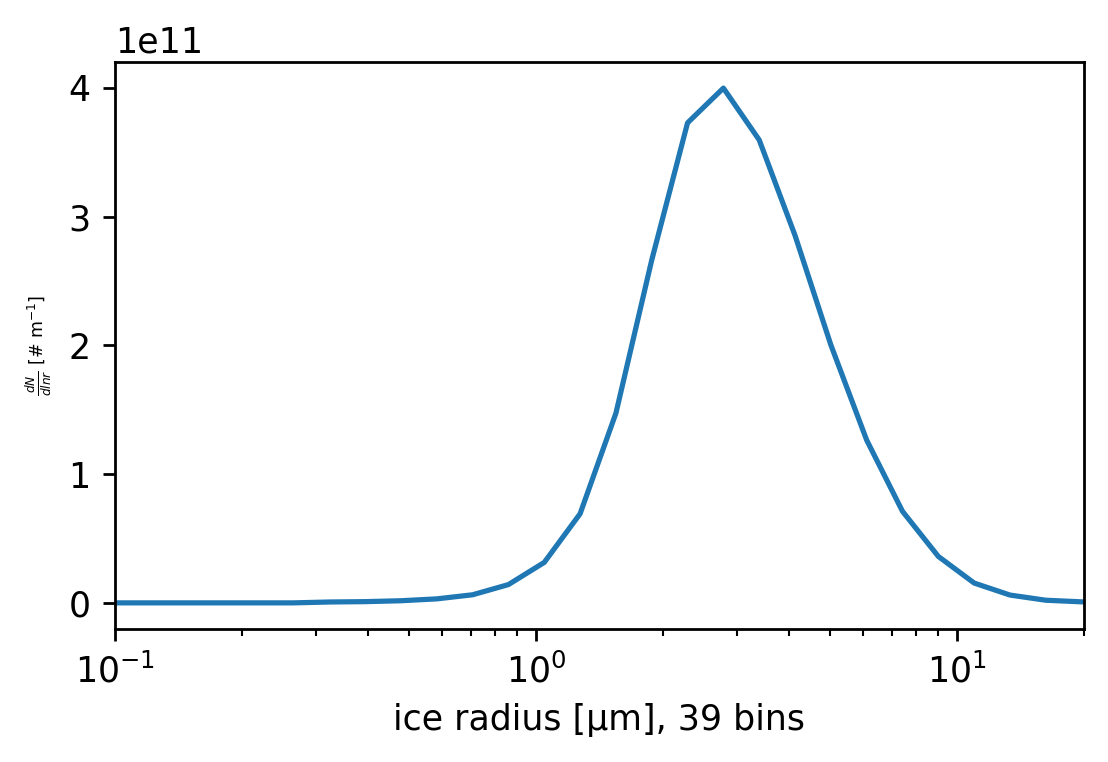

In [9]:
# Plot the number of ice particles per bin
plt.figure(figsize=(5,3), dpi=250)
plt.plot(bypass_dataset['ice_r'].values * 1e6, bypass_dataset['ice_pdf'].values * 1e6 * bypass_dataset['area'].values)
plt.xscale('log')
plt.xlabel('ice radius [µm], 39 bins')
plt.ylabel(r'$\frac{dN}{dlnr}$ [# m$^{-1}$]', fontsize=5)
plt.xlim(0.1, 20)
plt.show()

# LLES data scaling and conversion

In [10]:
# Import LLES data to match
if test_id.startswith("110"):
    LLES = pd.read_csv("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_crystal_radius/110T205L25/110T205L25_5min.csv")
else:
    LLES = pd.read_csv("/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/ice_crystal_radius/130T225L25/130T225L25_5min.csv")

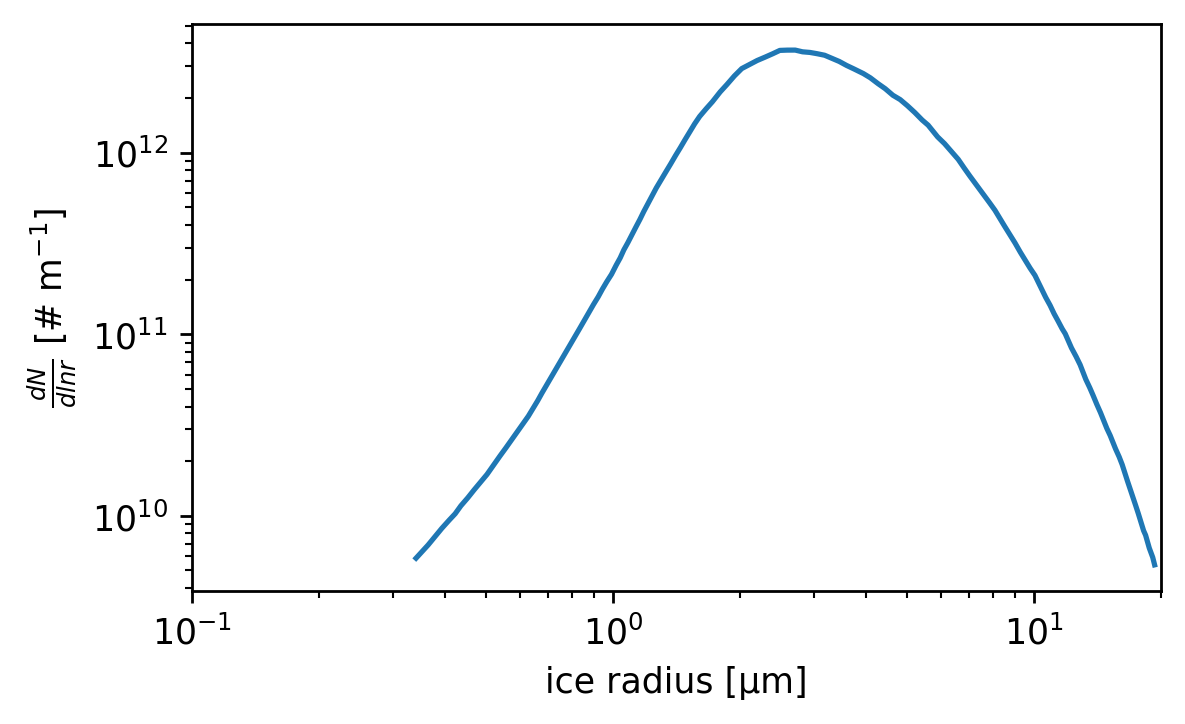

In [11]:
# Plot the unscaled LLES data with column 1 as x and column 2 as y
plt.figure(figsize=(5,3), dpi=250)
plt.plot(LLES.iloc[:,0], LLES.iloc[:,1])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('ice radius [µm]')
plt.ylabel(r'$\frac{dN}{dlnr}$ [# m$^{-1}$]', fontsize=10)
plt.xlim(0.1, 20)
plt.show()

In [12]:
# Bin the LLES data using the specified bin edges
bin_edges = bypass_dataset['ice_r_e'].values * 1e6  # Convert to µm
bin_indices = np.digitize(LLES.iloc[:,0], bin_edges) - 1

# Prepare arrays to store mean radius and mean value per bin
mean_radii = []
mean_values = []
bin_width = []
unscaled_total_ice_number_LES = 0

for i in range(len(bin_edges) - 1):
    mask = bin_indices == i
    if np.any(mask):
        bin_width.append(np.log(bin_edges[i+1]) - np.log(bin_edges[i]))
        mean_radii.append(bypass_dataset['ice_r'].values[i] * 1e6)  # Mean radius is the center of the bin
        mean_values.append(LLES.iloc[:,1][mask].mean())
    else:
        bin_width.append(np.log(bin_edges[i+1]) - np.log(bin_edges[i]))
        mean_radii.append(bypass_dataset['ice_r'].values[i] * 1e6)  # Mean radius is the center of the bin
        mean_values.append(0.0)

# Calculate the total ice number
for i in range(len(bin_width)):
    unscaled_total_ice_number_LES += mean_values[i] * bin_width[i]
print(f"LLES original total ice number, one engine [# m^-1]: {0.5*unscaled_total_ice_number_LES:.3e}")

LLES original total ice number, one engine [# m^-1]: 2.133e+12


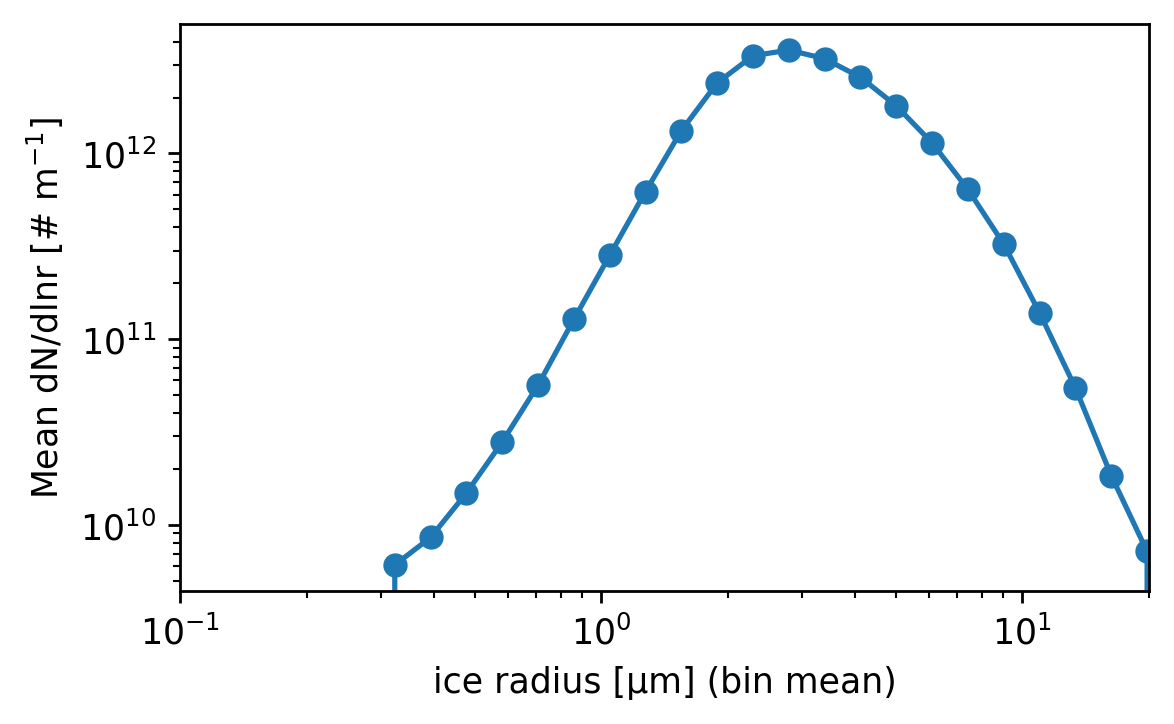

In [13]:
# Plot the binned means
plt.figure(figsize=(5,3), dpi=250)
plt.plot(mean_radii, mean_values, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('ice radius [µm] (bin mean)')
plt.ylabel('Mean dN/dlnr [# m$^{-1}$]')
plt.xlim(0.1, 20)
plt.show()

In [14]:
# Convert LLES to EPM PDF units
LLES_pdf_epm_format = mean_values / bypass_dataset['area'].values / 1e6 # #/m/cm3

# Check the total number of particles
particles_per_bin = LLES_pdf_epm_format* 1e6 * bypass_dataset['area'].values * 0.19592889

In [15]:
first_LLES_num_particles = 2.42845e12  # For 130%, 205, 218, 225: 4.90563e12, 2.42845e12, 1.78821e12
                                    # For 110%, 205, 218, 225: 3.58e12, 9.47e11, 5.88e11

# Add a factor of 0.5 as the epm will multiply by 2 engines
scaling = 0.5 * first_LLES_num_particles/np.sum(particles_per_bin)
scaled_particles_per_bin = scaling * particles_per_bin

In [16]:
scaled_ice_number_LES_one_eng = np.sum(scaled_particles_per_bin)

In [18]:
print(f"{scaled_ice_number_LES_one_eng:.3e}")

1.214e+12


## Save the scaled LES distribution to the epm-output.nc file

In [19]:
scaled_LLES_pdf_epm_format = scaling * LLES_pdf_epm_format

In [20]:
bypass_dataset['ice_pdf'].values = scaled_LLES_pdf_epm_format

In [21]:
bypass_dataset

<xarray.Dataset>
Dimensions:       (so4_r: 44, so4_r_e: 45, ice_r: 38, ice_r_e: 39)
Coordinates:
  * so4_r         (so4_r) float64 1.108e-10 1.348e-10 ... 4.154e-07 5.053e-07
  * so4_r_e       (so4_r_e) float64 1e-10 1.216e-10 ... 4.559e-07 5.546e-07
  * ice_r         (ice_r) float64 5.541e-08 6.74e-08 ... 6.41e-05 7.798e-05
  * ice_r_e       (ice_r_e) float64 5e-08 6.082e-08 ... 7.036e-05 8.559e-05
Data variables:
    finalTemp     float64 218.2
    iceRadius     float64 1.652e-06
    iceDensity    float64 540.2
    sootDensity   float64 0.0
    H2O_mol       float64 2.114
    SO4g_mol      float64 -4.313e-16
    SO4l_mol      float64 0.0
    area          float64 798.3
    bypassArea    float64 1.28
    coreExitTemp  float64 615.0
    so4_pdf       (so4_r) float64 5.246e-15 6.007e-14 ... 2.504e-97 1.873e-102
    ice_pdf       (ice_r) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

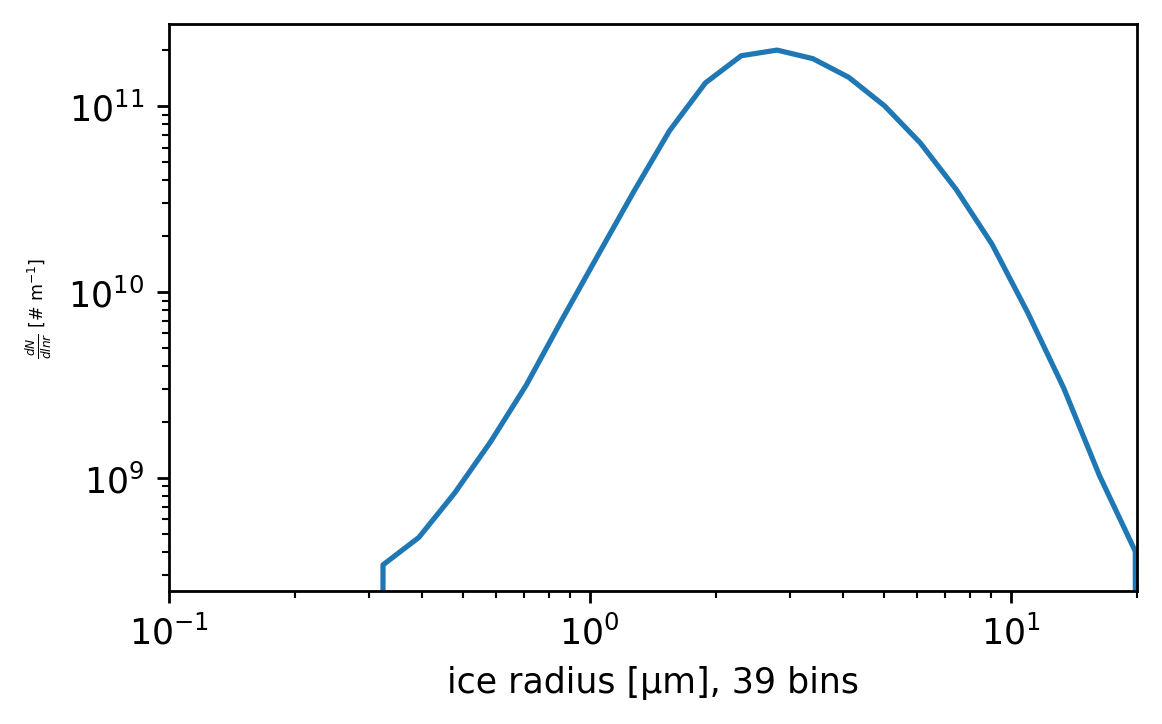

In [22]:
# Plot the number of ice particles per bin
plt.figure(figsize=(5,3), dpi=250)
plt.plot(bypass_dataset['ice_r'].values * 1e6, scaled_particles_per_bin)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('ice radius [µm], 39 bins')
plt.ylabel(r'$\frac{dN}{dlnr}$ [# m$^{-1}$]', fontsize=5)
plt.xlim(0.1, 20)
plt.show()

In [23]:
# Save the changes to the bypass_dataset
bypass_dataset.to_netcdf((f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/APCEMM/base_inputs/{test_id}/epm-input.nc"))